#Step 1: Set Dataset Paths

In [2]:
train_path = "/content/drive/MyDrive/MRI Detection/dataset/Training"
test_path  = "/content/drive/MyDrive/MRI Detection/dataset/Testing"

#Step 2: Import Libraries

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

#Step 3: Load Training Dataset

In [4]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 5600 files belonging to 4 classes.


#Step 4: Load Testing Dataset

In [5]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 1600 files belonging to 4 classes.


#Step 5: Check Class Names

In [6]:
class_names = train_data.class_names
print("Classes:", class_names)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


#Step 6: Normalize Images (VERY IMPORTANT)

In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data  = test_data.map(lambda x, y: (normalization_layer(x), y))

#Step 7: Visualize Some Images

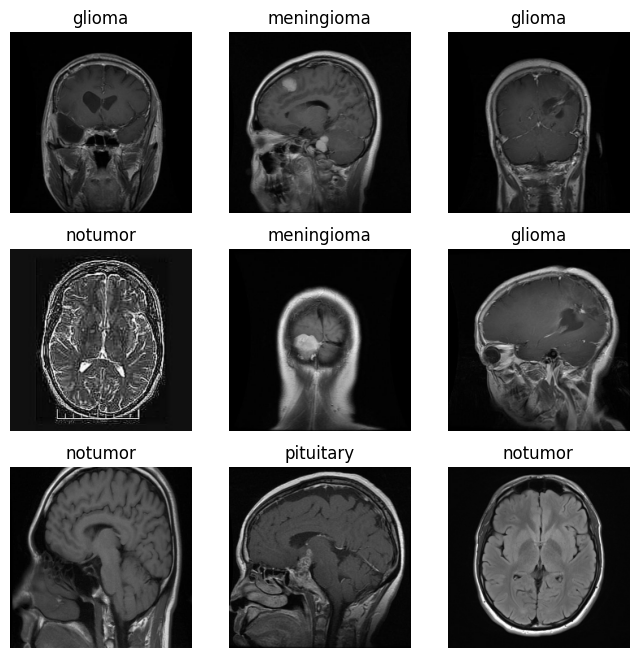

In [8]:
plt.figure(figsize=(8,8))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

#Load Pretrained MobileNetV2 (Without Top Layer)

In [10]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False   # Freeze base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Build Custom Model

In [11]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')   # 4 classes
])

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,468 (9.27 MB)

 Trainable params: 172,484 (673.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#Train Model

In [14]:
history = model.fit(train_data, validation_data=test_data, epochs=10)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 885s 5s/step - accuracy: 0.7280 - loss: 0.6456 - val_accuracy: 0.8425 - val_loss: 0.5949
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 165ms/step - accuracy: 0.8853 - loss: 0.3153 - val_accuracy: 0.8506 - val_loss: 0.5568
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.9049 - loss: 0.2507 - val_accuracy: 0.8619 - val_loss: 0.5772
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 28s 162ms/step - accuracy: 0.9166 - loss: 0.2255 - val_accuracy: 0.8794 - val_loss: 0.5212
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.9234 - loss: 0.2000 - val_accuracy: 0.8869 - val_loss: 0.5138
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.9305 - loss: 0.1840 - val_accuracy: 0.8944 - val_loss: 0.5339
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.9374 - loss: 0.1648 - val_accuracy: 0.9000 - val_loss: 0.5522
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 165ms/step - accuracy: 0.9366 - loss: 0.1

#Evaluate Model

In [15]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.7950 - loss: 1.4042
Test Accuracy: 0.8974999785423279


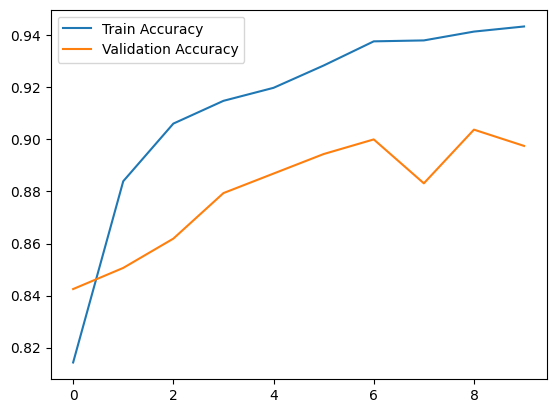

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

#Save Model

In [17]:
model.save("brain_tumor_model.h5")

In [18]:
from google.colab import files
files.download("brain_tumor_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Get True Labels and Predictions

In [19]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110

#Create Confusion Matrix

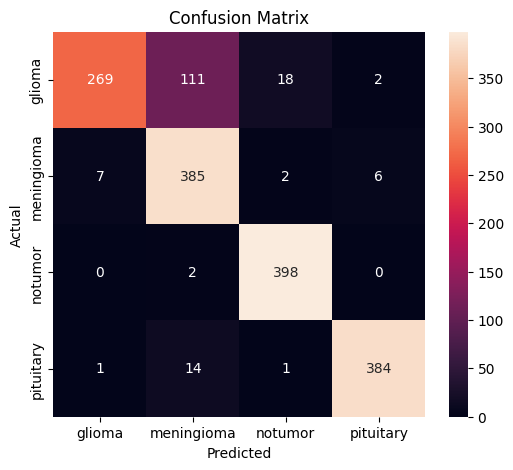

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Precision, Recall, F1 Score

In [21]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

      glioma       0.97      0.67      0.79       400
  meningioma       0.75      0.96      0.84       400
     notumor       0.95      0.99      0.97       400
   pituitary       0.98      0.96      0.97       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600

